# Defect Thermodynamics with Quantum Espresso output

Here, we calculate the carrier concentrations using doped similar to the workflow in GGA_workflow_tutorial.ipynb with data from quantum espresso.

In [5]:
from doped.thermodynamics import get_fermi_dos_from_espresso_dos, scissor_dos

MgO_dos = get_fermi_dos_from_espresso_dos(
    "MgO_qe/DOS/MgO_bulk_tetrahedra.dos",
    bulk_pwxml="MgO_qe/Defects/MgO_bulk/espresso_std/espresso.xml",
)


In [6]:
from pymatgen.io.vasp import VolumetricData
from doped.analysis import DefectsParser
%matplotlib inline

In [7]:
bulk_path = "MgO_qe/Defects/MgO_bulk"
dielectric = 8.8963

In [8]:
calc_root = "MgO_qe/Defects"
pp_folder = "pp_folder"

# Defect parser automatically parses the corrections with beta - 1.5(default). (Note that beta = 1.2 gives better values)
dp = DefectsParser(code = 'espresso',
                   output_path = calc_root,
                   dielectric=8.8963,
                   beta = 1.2,
                   pp_folder = pp_folder, bulk_path = bulk_path, processes = 1)


Parsing Mg_O_+1/espresso_std: 100%|██████████| 4/4 [00:39<00:00,  9.99s/it]
[PARSED_WITH_WARNING] Folder: Mg_O_+3 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+4 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+2 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+1 | Warning: Projected magnetisation not implemented for QE. Returning None.



In [9]:
from doped.chemical_potentials import CompetingPhasesAnalyzerQE
cpa_QE = CompetingPhasesAnalyzerQE(composition="MgO", entries="/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/Competing_phases_worked_examples")

Parsing QE `.xml` outputs...: 100%|██████████| 5/5 [00:00<00:00, 246.35it/s]


In [10]:
MgO_chempots_QE = cpa_QE.chempots

In [12]:
MgO_thermo_QE = dp.get_defect_thermodynamics(
    chempots=MgO_chempots_QE, band_gap=4.8099, bulk_dos = MgO_dos
)

The band gap of the bulk DOS calculation (VBM = 5.79 eV, band gap = 4.61 eV) differs by >0.05 eV from `DefectThermodynamics.vbm/gap` (VBM = 5.71 eV, band gap = 4.81 eV; which are taken from the bulk supercell calculation by default, unless `bulk_band_gap_vr` is set during defect parsing). This can cause inaccuracies in thermodynamics & concentration analyses; see https://doped.readthedocs.io/en/latest/Tips.html#density-of-states-dos-calculations for advice.
Note that the Fermi level will be always referenced to `DefectThermodynamics.vbm`!



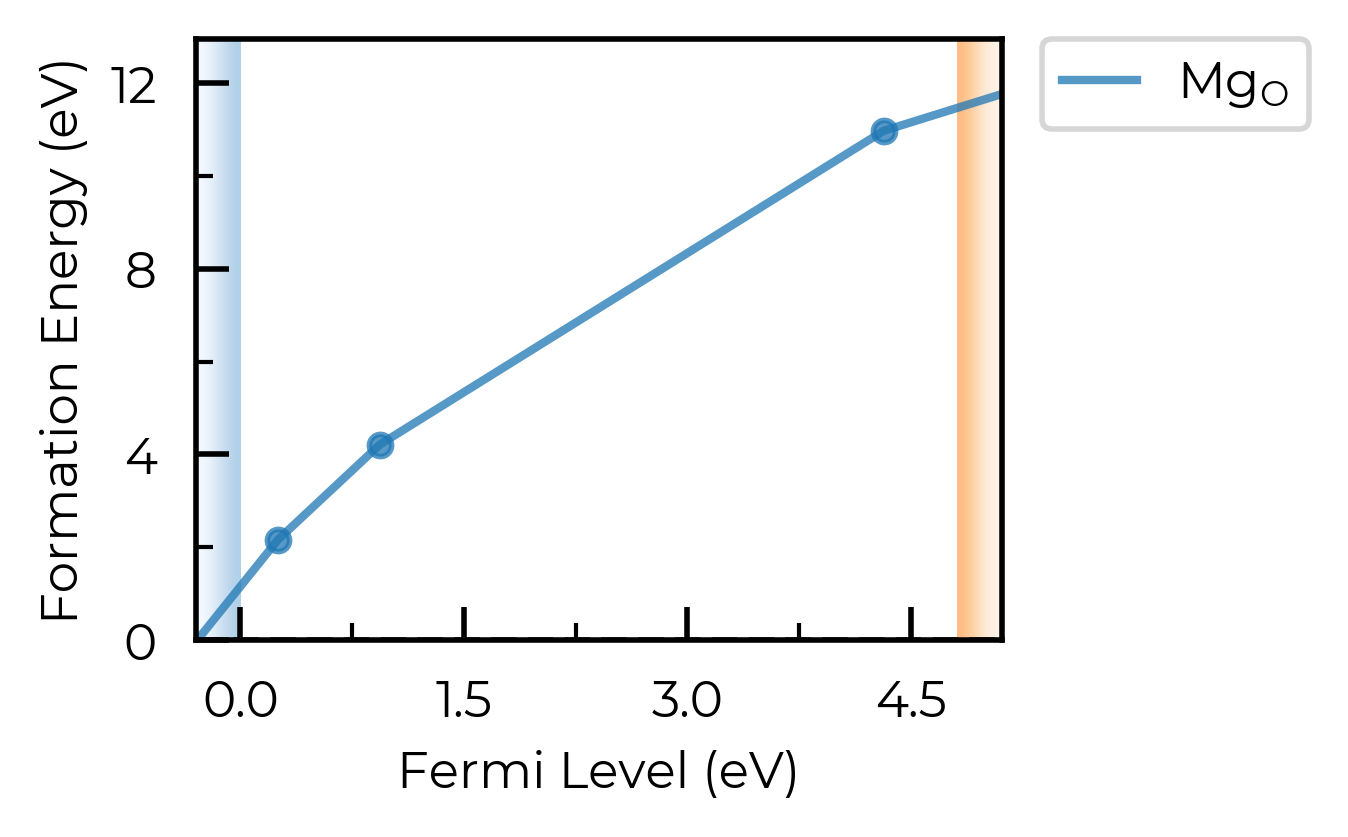

In [13]:
fig = MgO_thermo_QE.plot(limit="MgO-Mg", chempot_table=False)

In [14]:
cpa_QE.chempots_df

,Mg,O
Limit,,
MgO-Mg,0.00000,-5.38616
MgO-O2,-5.38616,0.00000


In [15]:
MgO_thermo_QE.get_symmetries_and_degeneracies()

Site_Symm Defect_Symm  g_Orient  g_Spin  g_Total  Mult
Defect q                                                        
Mg_O   +4        Oh         C2v      12.0     1.0     12.0   1.0
       +3        Oh         C3v       8.0     2.0     16.0   1.0
       +2        Oh         C3v       8.0     1.0      8.0   1.0
       +1        Oh          Cs      24.0     2.0     48.0   1.0

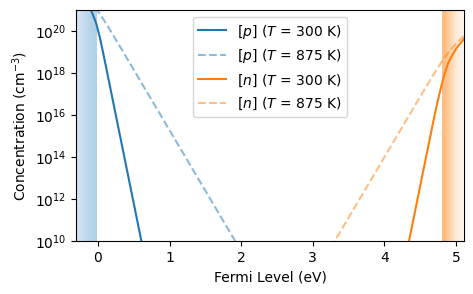

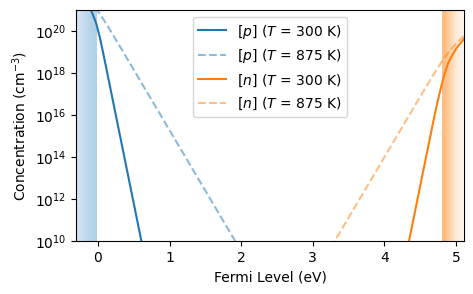

In [17]:
import numpy as np
import matplotlib.pyplot as plt

f,ax = plt.subplots(figsize=(5,3))
band_gap = MgO_thermo_QE.band_gap
anneal_T = 875
e_concs = []; h_concs = []; fermi_levels = np.linspace(-0.3, band_gap + 0.3, 100)
high_temp_e_concs = []; high_temp_h_concs = []
for fermi_level in fermi_levels:
    e_conc, h_conc = MgO_thermo_QE.bulk_dos.get_e_h_concs( fermi_level=MgO_thermo_QE.vbm + fermi_level, temperature=300)
    e_concs.append(e_conc); h_concs.append(h_conc)
    e_conc, h_conc = MgO_thermo_QE.bulk_dos.get_e_h_concs(
       fermi_level=MgO_thermo_QE.vbm + fermi_level, temperature=anneal_T)
    high_temp_e_concs.append(e_conc); high_temp_h_concs.append(h_conc)

ax.plot(fermi_levels, h_concs, label="$[p]$ ($T$ = 300 K)", color="C0")
ax.plot(fermi_levels, high_temp_h_concs, label=f"$[p]$ ($T$ = {anneal_T} K)", color="C0", ls="--", alpha=0.5)
ax.plot(fermi_levels, e_concs, label="$[n]$ ($T$ = 300 K)", color="C1")
ax.plot(fermi_levels, high_temp_e_concs, label=f"$[n]$ ($T$ = {anneal_T} K)", color="C1", ls="--", alpha=0.5)
ax.set_xlabel("Fermi Level (eV)"); ax.set_ylabel("Concentration (cm$^{-3}$)")
ax.legend(); ax.semilogy()

# show VB in blue from -0.3 to 0 eV and CB in orange from CBM to CBM + 0.3 eV:
ax.imshow([(0, 1), (0, 1)], cmap=plt.cm.Blues, extent=(ax.get_xlim()[0], 0, ax.get_ylim()[1], ax.get_ylim()[0]),
          vmin=0, vmax=3, interpolation="bicubic", rasterized=True, aspect="auto")

ax.imshow([(1, 0), (1, 0)], cmap=plt.cm.Oranges, extent=(band_gap, band_gap + 0.3, ax.get_ylim()[0], ax.get_ylim()[1]),
          vmin=0, vmax=3, interpolation="bicubic", rasterized=True, aspect="auto")
ax.set_xlim(-0.3, band_gap + 0.3); ax.set_ylim(1e10, 1e21);  # set axis limits
f

In [18]:
import numpy as np
from tqdm import tqdm

anneal_temperatures = np.arange(200, 1401, 50)  # annealing temperatures to consider, in K
annealing_dict = {}

for anneal_temp in tqdm(anneal_temperatures):
    (fermi_level, e_conc, h_conc, conc_df,
     annealing_fermi_level, annealing_e_conc, annealing_h_conc, _annealing_conc_df
     ) = MgO_thermo_QE.get_fermi_level_and_concentrations(
        bulk_dos=MgO_thermo_QE.bulk_dos, limit="Mg-rich", annealing_temperature=anneal_temp, skip_formatting=True,
        return_annealing_values=True,  # return annealing Fermi level & concentrations for comparison
    )  # quenching to 300K (default) – alternatively can specify quench (operating) temperature
    annealing_dict[anneal_temp] = {
        "annealing_fermi_level": annealing_fermi_level,
        "annealing_e_conc": annealing_e_conc,
        "annealing_h_conc": annealing_h_conc,
        "fermi_level": fermi_level,
        "e_conc": e_conc,
        "h_conc": h_conc,
        "conc_df": conc_df
    }

  0%|          | 0/25 [00:00<?, ?it/s]thermodynamics.py:3848: UserWarning: The band gap of the bulk DOS calculation (VBM = 5.79 eV, band gap = 4.61 eV) differs by >0.05 eV from `DefectThermodynamics.vbm/gap` (VBM = 5.71 eV, band gap = 4.81 eV; which are taken from the bulk supercell calculation by default, unless `bulk_band_gap_vr` is set during defect parsing). This can cause inaccuracies in thermodynamics & concentration analyses; see https://doped.readthedocs.io/en/latest/Tips.html#density-of-states-dos-calculations for advice.
Note that the Fermi level will be always referenced to `DefectThermodynamics.vbm`!
100%|██████████| 25/25 [00:00<00:00, 25.61it/s]


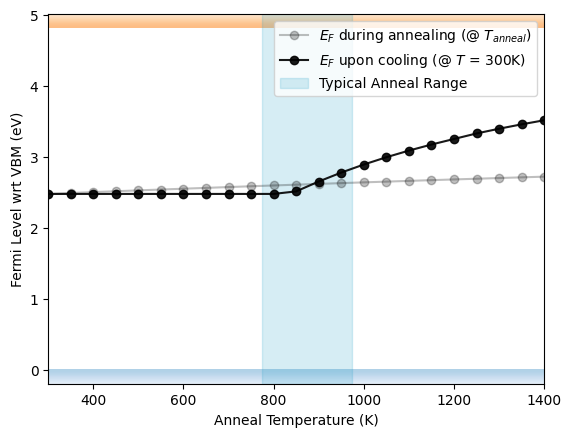

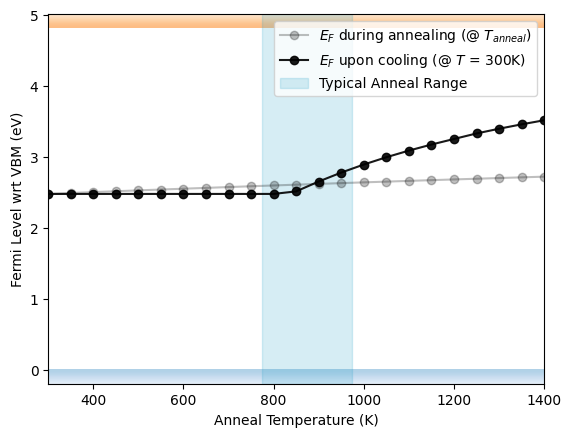

In [19]:
import matplotlib.pyplot as plt
f,ax = plt.subplots()

anneal_fermi_levels = np.array([v["annealing_fermi_level"] for k, v in annealing_dict.items()])
quenched_fermi_levels = np.array([v["fermi_level"] for k, v in annealing_dict.items()])
ax.plot(anneal_temperatures, anneal_fermi_levels, marker='o',
        label="$E_F$ during annealing (@ $T_{anneal}$)", color = "k", alpha=0.25)
ax.plot(anneal_temperatures, quenched_fermi_levels, marker='o',
        label="$E_F$ upon cooling (@ $T$ = 300K)", color = "k", alpha=0.9)
ax.set_xlabel('Anneal Temperature (K)')
ax.set_ylabel('Fermi Level wrt VBM (eV)')
ax.set_xlim(300, 1400)
ax.axvspan(500+273.15, 700+273.15, alpha=0.2, color='#33A7CC', label="Typical Anneal Range")
ax.legend()

# show VB in blue and CB in orange:
ax.imshow([(1, 1), (0, 0)], cmap=plt.cm.Blues, extent=(ax.get_xlim()[0], ax.get_xlim()[1], -0.3, 0),
          vmin=0, vmax=3, interpolation="bicubic", rasterized=True, aspect="auto")
ax.imshow([(0, 0,), (1, 1)], cmap=plt.cm.Oranges, extent=(ax.get_xlim()[0], ax.get_xlim()[1], band_gap, band_gap+0.3),
          vmin=0, vmax=3, interpolation="bicubic", rasterized=True, aspect="auto",)
ax.set_ylim(-0.2, band_gap+0.2)
f

In [20]:
fermi_level, e_conc, h_conc, conc_df = MgO_thermo_QE.get_fermi_level_and_concentrations(
    limit="Mg-rich", annealing_temperature=1400  # annealing temperature in Kelvin
)
print(f"Self-consistent Fermi level for MgO under Mg-rich conditions, annealed at 1400 K, quenched to 300 K (and using the un-physical example case of only Mg_O defects): {fermi_level:.2f} eV relative to VBM")
print(f"Electron concentration: {e_conc:.2e} cm^-3")
print(f"Hole concentration: {h_conc:.2e} cm^-3")

Self-consistent Fermi level for MgO under Mg-rich conditions, annealed at 1400 K, quenched to 300 K (and using the un-physical example case of only Mg_O defects): 3.51 eV relative to VBM
Electron concentration: 1.11e-04 cm^-3
Hole concentration: 1.44e-39 cm^-3


In [21]:
from doped.thermodynamics import FermiSolver

fs = FermiSolver(MgO_thermo_QE)
conc_df = fs.scan_temperature(
    limit="Mg-rich",
    annealing_temperature_range = range(300, 1310, 50)  # temperatures to scan over, in K,
)
conc_df

100%|██████████| 21/21 [00:00<00:00, 23.37it/s]


Concentration (cm^-3)  Formation Energy (eV)  \
Defect Charge                                                 
Mg_O   4               5.399193e-128                 11.051   
       3               4.561193e-125                  8.826   
       2                1.630362e-99                  7.287   
       1               5.399193e-128                  9.130   
       4               6.929504e-111                 11.051   
...                              ...                    ...   
       1                8.393542e-09                  9.983   
       4                1.106769e-07                 14.727   
       3                1.106769e-07                 11.584   
       2                1.106769e-07                  9.126   
       1                1.106769e-07                 10.049   

              Charge State Population  Total Concentration (cm^-3)  \
Defect Charge                                                        
Mg_O   4                        0.00%                 1.630362e-99   
       3                        0.00%                 1.630362e-99   
       2                      100.00%                 1.630362e-99   
       1                        0.00%                 1.630362e-99   
       4                        0.00%                 2.092461e-82   
...                               ...                          ...   
       1                       25.00%                 3.357417e-08   
       4                       25.00%                 4.427075e-07   
       3                       25.00%                 4.427075e-07   
       2                       25.00%                 4.427075e-07   
       1                       25.00%                 4.427075e-07   

               Annealing Temperature (K)  Quenched Temperature (K)  \
Defect Charge                                                        
Mg_O   4                             300                       300   
       3                             300                       300   
       2                             300                       300   
       1                             300                       300   
       4                             350                       300   
...                                  ...                       ...   
       1                            1250                       300   
       4                            1300                       300   
       3                            1300                       300   
       2                            1300                       300   
       1                            1300                       300   

               Fermi Level (eV wrt VBM)  Electrons (cm^-3)  Holes (cm^-3)  \
Defect Charge                                                               
Mg_O   4                       2.475266       4.002344e-22   4.002344e-22   
       3                       2.475266       4.002344e-22   4.002344e-22   
       2                       2.475266       4.002344e-22   4.002344e-22   
       1                       2.475266       4.002344e-22   4.002344e-22   
       4                       2.475266       4.002344e-22   4.002344e-22   
...                                 ...                ...            ...   
       1                       3.327781       8.393542e-08   1.908462e-36   
       4                       3.394457       1.106769e-06   1.447344e-37   
       3                       3.394457       1.106769e-06   1.447344e-37   
       2                       3.394457       1.106769e-06   1.447344e-37   
       1                       3.394457       1.106769e-06   1.447344e-37   

               μ_Mg (eV)  μ_O (eV)  
Defect Charge                       
Mg_O   4             0.0  -5.38616  
       3             0.0  -5.38616  
       2             0.0  -5.38616  
       1             0.0  -5.38616  
       4             0.0  -5.38616  
...                  ...       ...  
       1             0.0  -5.38616  
       4             0.0  -5.38616  
 

We can calculate the carrier concentrations for every charged defect with the following method as done in the GGA_workflow_tutorial.ipynb

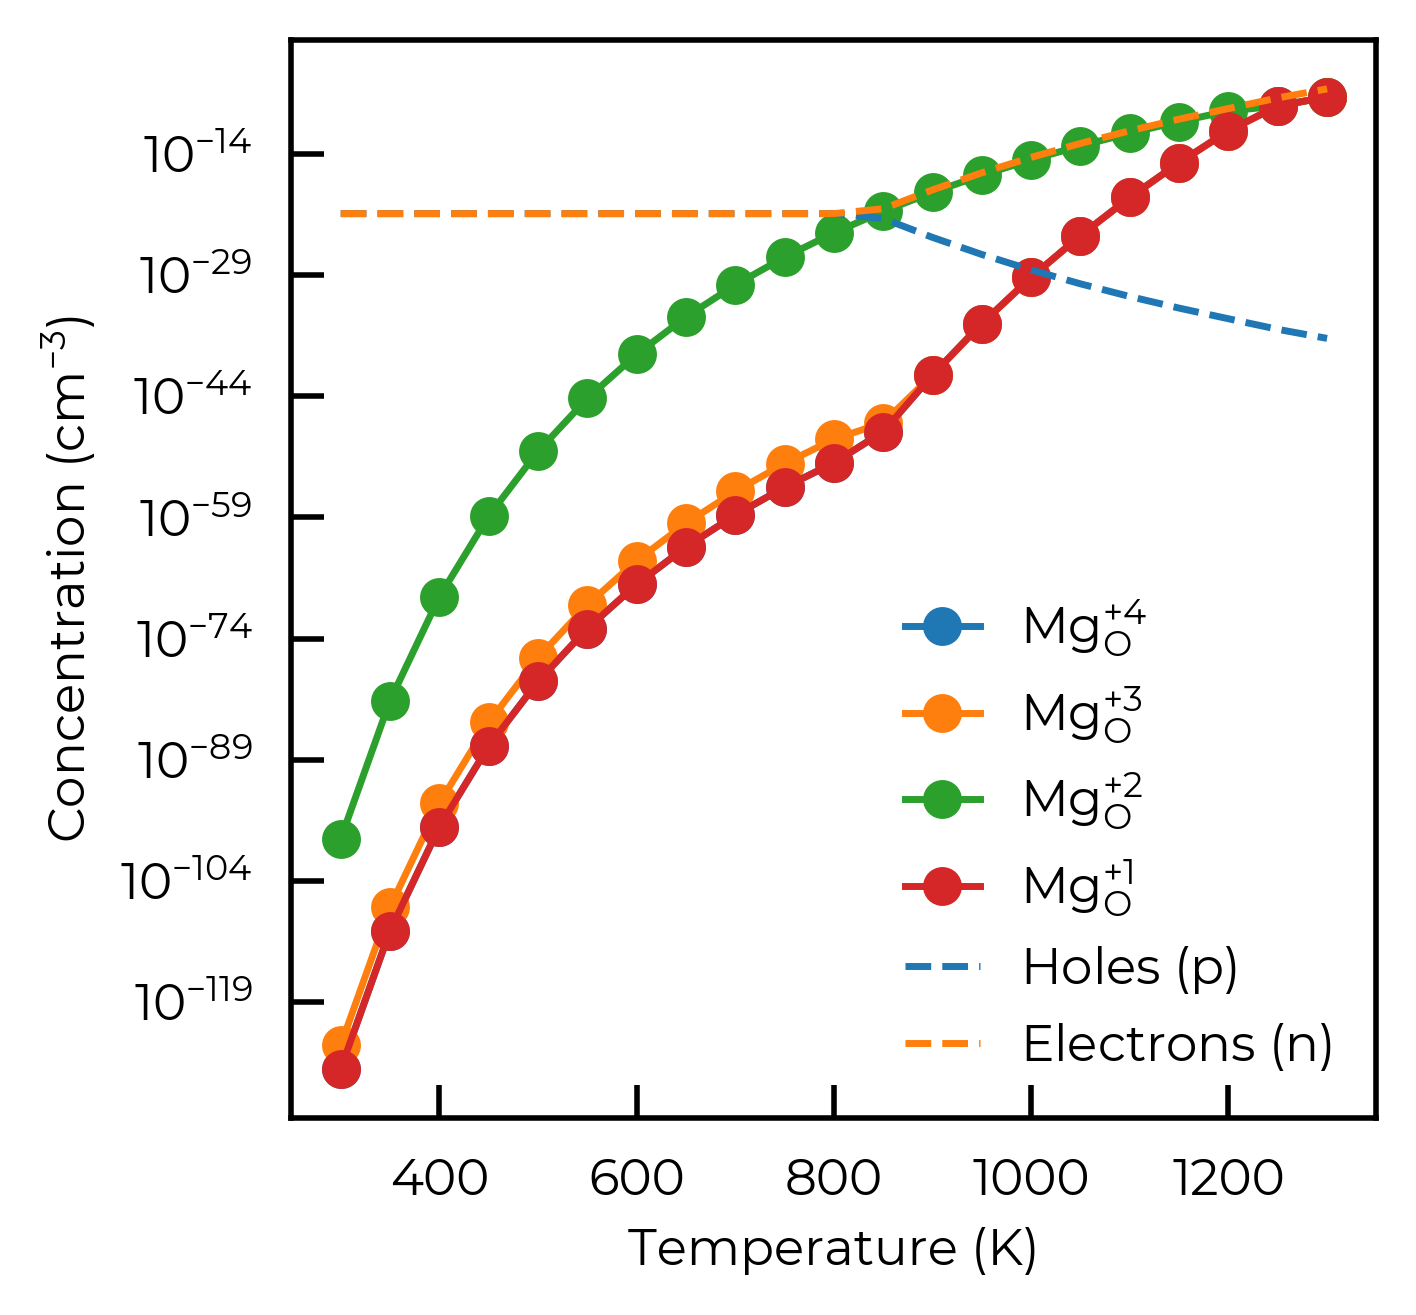

In [22]:
import matplotlib.pyplot as plt
import doped
from doped.utils.plotting import format_defect_name

plt.style.use(f"{doped.__path__[0]}/utils/doped.mplstyle")  # consistent doped plot style

fig, ax = plt.subplots()
for defect in conc_df.index.unique():  # plot the defect concentration(s)
    defect_df = conc_df.loc[[defect]]
    defect_name = f"{defect[0]}_{defect[1]}"
    ax.plot(defect_df["Annealing Temperature (K)"], defect_df["Concentration (cm^-3)"],
            marker="o", label=format_defect_name(defect_name))

# the carrier concentrations are the same for every defect row at a given
# temperature, so we just take one row per temperature:
carrier_df = conc_df.drop_duplicates("Annealing Temperature (K)")
ax.plot(carrier_df["Annealing Temperature (K)"], carrier_df["Holes (cm^-3)"],
        linestyle="--", color="C0", label="Holes ($p$)")
ax.plot(carrier_df["Annealing Temperature (K)"], carrier_df["Electrons (cm^-3)"],
        linestyle="--", color="C1", label="Electrons ($n$)")

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Concentration (cm$^{-3}$)")
ax.set_yscale("log")
ax.legend(frameon=False)
plt.show()

## Carrier concentrations with a another bulk DOS: VASP DOS vs QE DOS

The VASP bulk DOS used in `GGA_workflow_tutorial.ipynb` was computed with Gaussian smearing (`ISMEAR = 0`), which softens the band edges and narrows the band gap. Below we compare two ways of supplying a corrected bulk DOS to the **same VASP defect energetics** (`MgO_thermo_VASP`), so the only thing that changes is the DOS:

1. **VASP DOS, gap-scissored** — take the smeared VASP DOS and raise its conduction band (`delta_CBM`) so the gap matches the QE gap.
2. **QE DOS, rigidly shifted** — take the (sharp, tetrahedron-method) QE DOS and rigidly shift it (equal `delta_VBM` and `delta_CBM`) so its VBM lands on the VASP VBM.


In [42]:
from monty.serialization import loadfn


MgO_thermo_VASP = loadfn("./MgO/MgO_thermo.json.gz")
MgO_thermo_VASP.bulk_dos = "MgO/MgO_DOS_vasprun.xml.gz"
vasp_raw_dos = MgO_thermo_VASP.bulk_dos

In [43]:

MgO_thermo_VASP.bulk_dos.get_gap() - MgO_thermo_QE.bulk_dos.get_gap()

np.float64(-0.7306439966529572)

In [44]:
from doped.thermodynamics import scissor_dos

#  QE DOS rigidly shifted onto the VASP energy reference: move the QE DOS so its VBM lands on
# the VASP VBM (equal shift of VBM and CBM => gap preserved).
qe_to_vasp_shift = MgO_thermo_VASP.vbm - MgO_thermo_QE.vbm

# Using two scissors to avoid the error for avoiding delta_gap = 0 error.
shifted_qe_dos = scissor_dos(MgO_dos, delta_VBM=qe_to_vasp_shift)
shifted_qe_dos_final = scissor_dos(shifted_qe_dos, delta_CBM=qe_to_vasp_shift)

Orig gap: 4.6000, new gap:7.1852
Orig gap: 7.2000, new gap:4.6148


thermodynamics.py:5164: UserWarning: The new band gap does not appear to be equal to the original band gap plus the scissor shift, suggesting an error in `scissor_dos`, beware!
Got original gap (from manual indexing): 4.8, 4.60002105308901 from dos.get_gap(tol=tol) and new gap: 7.185199634117707
thermodynamics.py:5164: UserWarning: The new band gap does not appear to be equal to the original band gap plus the scissor shift, suggesting an error in `scissor_dos`, beware!
Got original gap (from manual indexing): 7.385178581028697, 7.200016291626566 from dos.get_gap(tol=tol) and new gap: 4.61483771059787


In [45]:

vasp_to_qe_gap_shift = MgO_thermo_QE.bulk_dos.get_gap() - vasp_raw_dos.get_gap()
shifted_vasp_dos = scissor_dos(vasp_raw_dos, delta_CBM=vasp_to_qe_gap_shift)

Orig gap: 3.9272, new gap:4.6578


thermodynamics.py:5164: UserWarning: The new band gap does not appear to be equal to the original band gap plus the scissor shift, suggesting an error in `scissor_dos`, beware!
Got original gap (from manual indexing): 4.207800000000001, 3.9272044863605147 from dos.get_gap(tol=tol) and new gap: 4.657848483013472


In [46]:
from copy import deepcopy

# Building two DefectThermodynamics objects with the SAME VASP defect energetics but different bulk DOS.

MgO_thermo_VASP_with_QE_DOS = deepcopy(MgO_thermo_VASP)

MgO_thermo_VASP.bulk_dos = shifted_vasp_dos         #VASP DOS, gap scissored to QE gap
MgO_thermo_VASP_with_QE_DOS.bulk_dos = shifted_qe_dos_final  # QE DOS, rigidly shifted to VASP VBM

thermodynamics.py:3848: UserWarning: The VBM eigenvalue of the bulk DOS calculation (VBM = 3.59 eV, band gap = 4.69 eV) differs by >0.05 eV from `DefectThermodynamics.vbm/gap` (VBM = 3.13 eV, band gap = 4.72 eV; which are taken from the bulk supercell calculation by default, unless `bulk_band_gap_vr` is set during defect parsing). This can cause inaccuracies in thermodynamics & concentration analyses; see https://doped.readthedocs.io/en/latest/Tips.html#density-of-states-dos-calculations for advice.
Note that the Fermi level will be always referenced to `DefectThermodynamics.vbm`!
thermodynamics.py:3848: UserWarning: The band gap of the bulk DOS calculation (VBM = 3.20 eV, band gap = 4.60 eV) differs by >0.05 eV from `DefectThermodynamics.vbm/gap` (VBM = 3.13 eV, band gap = 4.72 eV; which are taken from the bulk supercell calculation by default, unless `bulk_band_gap_vr` is set during defect parsing). This can cause inaccuracies in thermodynamics & concentration analyses; see https://d

In [47]:
import pandas as pd

runs = {
    "VASP DOS (gap scissored to QE gap)": MgO_thermo_VASP,
    "QE DOS (rigidly shifted to VASP VBM)": MgO_thermo_VASP_with_QE_DOS,
}
comparison = {}
for label, thermo in runs.items():
    fermi_level, e_conc, h_conc, _conc_df = thermo.get_fermi_level_and_concentrations(
        limit="Mg-rich", annealing_temperature=1400,  # anneal at 1400 K, quench to 300 K
    )
    comparison[label] = {
        "E_F (eV wrt VBM)": f"{fermi_level:.3f}",
        "n (cm^-3)": f"{e_conc:.3e}",
        "p (cm^-3)": f"{h_conc:.3e}",
    }

comparison_df = pd.DataFrame(comparison).T
print("Self-consistent Fermi level & carrier concentrations (Mg-rich, anneal 1400 K -> quench 300 K):")
comparison_df

Self-consistent Fermi level & carrier concentrations (Mg-rich, anneal 1400 K -> quench 300 K):


,E_F (eV wrt VBM),n (cm^-3),p (cm^-3)
VASP DOS (gap scissored to QE gap),3.951,1.191e-04,7.693e-43
QE DOS (rigidly shifted to VASP VBM),3.613,5.236e-03,3.059e-41
